# Project

In [1]:
import pandas as pd
#from thefuzz import process
#from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

# For imputation
#from sklearn.experimental import enable_iterative_imputer  # noqa
#from sklearn.impute import IterativeImputer

from scipy import stats
from sklearn.feature_selection import VarianceThreshold, RFE
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier #, ExtraTreesRegressor
from sklearn.tree import DecisionTreeRegressor

import numpy as np
from sklearn.base import BaseEstimator, clone
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from typing import Dict

from sklearn.linear_model import LinearRegression, ElasticNet
from sklearn.neighbors import KNeighborsRegressor

from sklearn.preprocessing import RobustScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

import matplotlib.pyplot as plt
from sklearn.neural_network import MLPRegressor

import random
from copy import deepcopy
import time

import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.cluster import DBSCAN

In [2]:
import sys
import os

# Add the current directory to sys.path so we can import from Functions
if os.getcwd() not in sys.path:
    sys.path.append(os.getcwd())

# Import Preprocessing functions
from Functions.preprocessing import (
    simple_processing, 
    remove_price_outliers, 
    fit_transform_encoding, 
    decode, 
    minimal_features
)

# Import Imputation functions
from Functions.imputation import (
    mode_imputation, 
    fit_imputer, 
    apply_imputer, 
    fit_price_imputer, 
    apply_price_imputer
)

from Functions.Engineering import *

from Functions.Train import *

from Functions.Selection import *
# Import

In [3]:
train_df = pd.read_csv("https://raw.githubusercontent.com/LiberoBiagi/ML_Nova_IMS_25-26/refs/heads/main/data/train.csv")

In [4]:
train_df = train_df.set_index("carID")
train_df = train_df.drop(columns=["paintQuality%"])

In [5]:
#train_df.head()

### Making sure that the model prices are not typos

In [6]:
"""
#df_cleaned = simple_processing(train_df)
#df_cleaned = df_cleaned[df_cleaned["model"].notna()]
#df_price_model = df_cleaned[["Brand","model", "price"]].copy()

# Get the list of unique models
models = df_price_model['model'].unique()

# Loop through each model and create a boxplot
#for model in models:
sns.catplot(data=df_price_model, y='price', col='model', kind='box', col_wrap=4, height=3, sharey=False)
plt.show()"""

'\n#df_cleaned = simple_processing(train_df)\n#df_cleaned = df_cleaned[df_cleaned["model"].notna()]\n#df_price_model = df_cleaned[["Brand","model", "price"]].copy()\n\n# Get the list of unique models\nmodels = df_price_model[\'model\'].unique()\n\n# Loop through each model and create a boxplot\n#for model in models:\nsns.catplot(data=df_price_model, y=\'price\', col=\'model\', kind=\'box\', col_wrap=4, height=3, sharey=False)\nplt.show()'

## Data cleaning

## Workflow for Train and Validation Sets

TODO: Explanation

#### Encoding

In [7]:
# Fix typos and small numeric cleanup
df = simple_processing(train_df)

# Remove extreme price outliers
df = remove_price_outliers(df)

# Encode cateogrical columns and replace the str with int columns. Return fitted encoders for decoding at the end
df_encoded, encoders = fit_transform_encoding(df)

#### Creating the stratification column

In [8]:
# Create Categorical price column with 0 < 1 < 2 for the price
df_encoded["price_cat"] = pd.qcut(df_encoded["price"], 3, labels=False)

# Combine the 10 unique brand values (1-9 & NA) with the 3 unique price category values (0-2)
stratify_col = df_encoded["Brand_transformed"].astype(str) + "_" + df_encoded["price_cat"].astype(str)

#### Imputation and decoding

In [9]:
# Train validation split
train_split, validation_split = train_test_split(df_encoded, test_size=0.2, random_state=69, stratify=stratify_col)
# train_split, validation_split = train_test_split(df_encoded, test_size=0.2, random_state=42)

# Drop price_cat column from both splits as it would introduce data leakage
train_split = train_split.drop("price_cat", axis=1)
validation_split = validation_split.drop("price_cat", axis=1)

train_split = mode_imputation(train_split)
validation_split = mode_imputation(validation_split)

# Train imputer on train (data leakage risk thus only train on train_split)
imputer = fit_imputer(train_split)

# Apply trained imputer to both datasplits
imputed_train = apply_imputer(train_split, imputer)
imputed_validation = apply_imputer(validation_split, imputer)

# Impute the missing price values created by removing extrem outliers
# In our step to remove extrem price outliers we introduced missing values in the price column. However, in our normal imputer, which we also use for imputing the test 
# Dataset we can not fix these values as this would cause the imputer to not work on the test subset, with no price feature. 
# Thus we create a seperate price imputer to fix the missing values in the testing and validation sets. This imputer is trained on train and applied to validation
# Fit price imputer
price_imputer = fit_price_imputer(imputed_train)
# Apply price imputer
imputed_train = apply_price_imputer(imputed_train, price_imputer)
imputed_validation = apply_price_imputer(imputed_validation, price_imputer)

# Decode encoded columns using the fitted encoders
train_processed = decode(imputed_train, encoders)
validation_processed = decode(imputed_validation, encoders)

c:\Users\liber\anaconda3\envs\ML_env\Lib\site-packages\sklearn\impute\_iterative.py:895: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(


## Workflow for Cleaning Testing Dataset

We use all the information available from the training data sets (train and validation splits) to fit imputers and preprocess the testing dataset. This should create a scenario as close to real world deployment as possible, where we use our existing data to process new data entries.

In [10]:
test_df = pd.read_csv("https://raw.githubusercontent.com/LiberoBiagi/ML_Nova_IMS_25-26/refs/heads/main/data/test.csv")

In [11]:
test_df = test_df.set_index("carID")
test_df = test_df.drop(columns=["paintQuality%"])

### Simple pre Imputation processing of Test data

In [12]:
test = simple_processing(test_df)

test_df_encoded, test_encoders = fit_transform_encoding(test)

### Fit the full testing imputer

In [13]:
# Preprocess the full training dataframe from scratch
df = simple_processing(train_df)
df = remove_price_outliers(df)
df_encoded, encoders = fit_transform_encoding(df)
train_df_mode_imputed = mode_imputation(df_encoded)

# Train a full imputer on the all available training data
full_training_imputer = fit_imputer(train_df_mode_imputed)

c:\Users\liber\anaconda3\envs\ML_env\Lib\site-packages\sklearn\impute\_iterative.py:895: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(


### Apply the full imputer to the testing data

In [14]:
#df_encoded_no_price = test_df_imputed.drop(["price", "price_cat"], axis=1)

# Apply imputer trained on testing data
test_df_imputed = apply_imputer(test_df_encoded, full_training_imputer)

test_processed = decode(test_df_imputed, test_encoders)

In [15]:
train_val_models = set(pd.concat([train_processed, validation_processed])["model"].unique())
test_models = set(test_processed["model"].unique())

missing_models = train_val_models - test_models


In [16]:
list(missing_models)


['urban cruiser',
 'verso-s',
 'getz',
 's8',
 'ranger',
 'kadjar',
 '230',
 'caddy maxi',
 '220',
 '200',
 'escort',
 'accent',
 'streetka']

## Checking our data

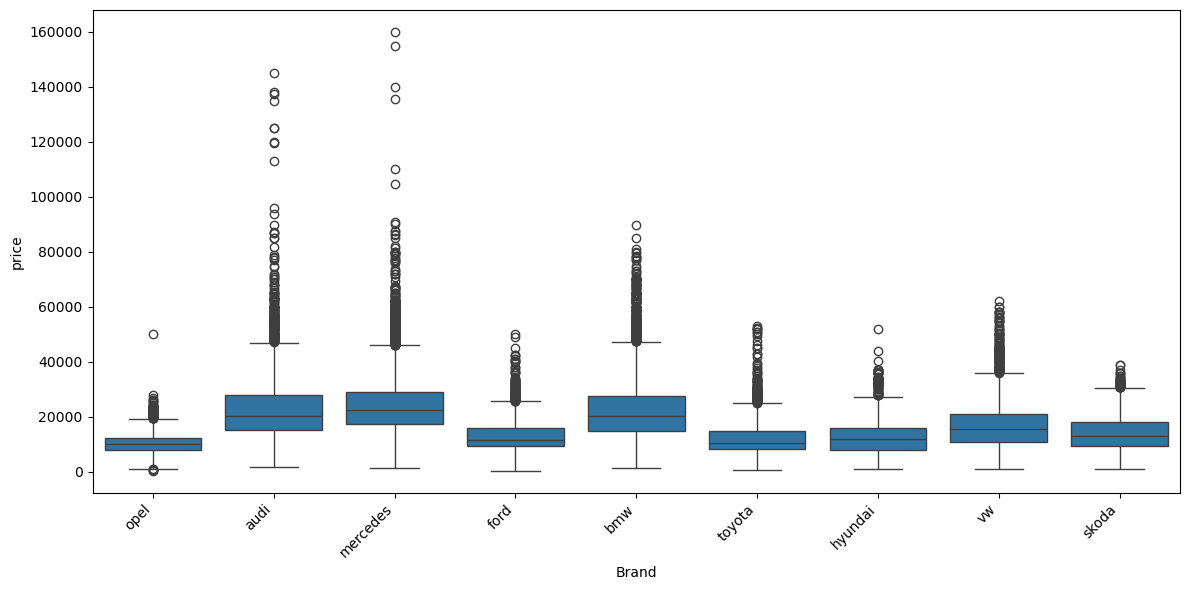

In [17]:
# Boxlpots for every brand.
plt.figure(figsize=(12, 6))
sns.boxplot(data=train_processed, x='Brand', y='price')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# There seem to be extreme values in our data for different brands, which might not seem to be outliers when observing our dataset as a whole. 
# We can assume that not only for brands do these types of outliers exist, but also for models. 

In [18]:
def remove_outliers_by_group(df, group_col, value_col, iqr_multiplier=1.5):
    """Remove outliers within each group based on the IQR method."""
    
    def filter_outliers(group):
        Q1 = group[value_col].quantile(0.25)
        Q3 = group[value_col].quantile(0.75)
        IQR = Q3 - Q1
        
        lower_bound = Q1 - iqr_multiplier * IQR
        upper_bound = Q3 + iqr_multiplier * IQR
        
        return group[(group[value_col] >= lower_bound) & (group[value_col] <= upper_bound)]
    
    return df.groupby(group_col, group_keys=False).apply(filter_outliers)

# Remove price outliers for each model separately
#train_cleaned = remove_outliers_by_group(train_processed, group_col='model', value_col='price')

# Display statistics
#print(f"Original shape: {train_processed.shape}")
#print(f"After removing outliers: {train_cleaned.shape}")
#print(f"Number of outliers removed: {train_processed.shape[0] - train_cleaned.shape[0]}")
#print(f"Percentage of data removed: {((train_processed.shape[0] - train_cleaned.shape[0]) / train_processed.shape[0] * 100):.2f}%")

#train_processed = train_cleaned

# It works well but we lose a lot of data. (2.57% if we take the iqr*1.5)

# If this is too much of a loss, we can try a different iqr multiplier, 2x for example.

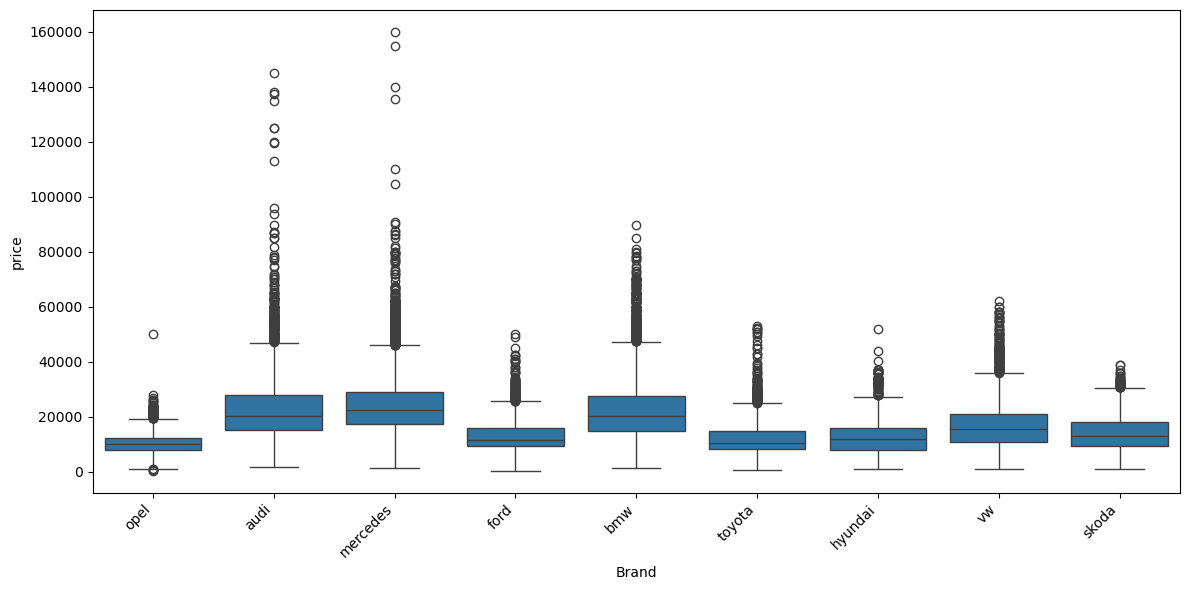

In [19]:
# Visualize boxplot after outlier removal
plt.figure(figsize=(12, 6))
sns.boxplot(data=train_processed, x='Brand', y='price')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [20]:
# Checking the audi models with the highest prices
brand_name = 'audi'
brand_avg = train_processed[train_processed['Brand'] == brand_name].groupby('model')['price'].mean().sort_values(ascending=False)
print(brand_avg)
print("\nThe audi cars descending by price:\n")

audi_cars = train_processed[train_processed['Brand'] == 'audi'][['model', 'price']].sort_values('price', ascending=False)
print(audi_cars)

# After cleaning the outliers and looking at the boxplots for all brands audi was seemingly the only brand with large extreme values,
# however these prices all belong to the r8 model which is known to be expensive.

# The cleaning seemed to be effective.

model
r8              96091.666667
q8              58339.969697
proace verso    56375.000000
ranger          56000.000000
rs6             53786.497575
                    ...     
s5              11495.000000
eos             10988.000000
a2              10759.727273
arteon           9990.000000
auris            8490.000000
Name: price, Length: 111, dtype: float64

The audi cars descending by price:

      model     price
10483    r8  145000.0
1082     r8  137995.0
42802    r8  137500.0
16774    r8  135000.0
43634    r8  125000.0
...     ...       ...
56952    a4    2675.0
8788     a6    2495.0
1203     a2    2490.0
46747    a6    2490.0
56299    a4    1699.0

[5970 rows x 2 columns]


## Feature Engineering

In [21]:
train_processed.index = train_processed.index.astype(int)
validation_processed.index = validation_processed.index.astype(int)

In [22]:
X_train = train_processed
X_val = validation_processed

In [24]:
X_train = minimal_features(X_train)
X_val = minimal_features(X_val)

In [ ]:
model_mean_price = X_train.groupby('model')['price'].mean()

X_train['model_mean_price'] = X_train['model'].map(model_mean_price)
X_val['model_mean_price']   = X_val['model'].map(model_mean_price)

model_std_price = X_train.groupby("model")["price"].std()

model_std_price = model_std_price.fillna(0) 

X_train['model_std_price'] = X_train['model'].map(model_std_price)

X_val['model_std_price'] = X_val['model'].map(model_std_price).fillna(0)

model_median_price = X_train.groupby("model")["price"].median()
X_train['model_median_price'] = X_train['model'].map(model_median_price)
X_val['model_median_price']   = X_val['model'].map(model_median_price)



In [26]:
y_train = X_train['price']
y_val = X_val['price']

In [ ]:
X_train, X_val = smoothed_mean_encoding(X_train, X_val, y_train, 'model', m=20)
X_train, X_val = smoothed_mean_encoding(X_train, X_val, y_train, 'Brand', m=50)

In [28]:
X_train = X_train.drop(columns=['price', "model"])

X_val = X_val.drop(columns=['price', "model"])


In [29]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 60778 entries, 0 to 60777
Data columns (total 20 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   mileage                    60778 non-null  int32  
 1   tax                        60778 non-null  int32  
 2   mpg                        60778 non-null  float64
 3   engineSize                 60778 non-null  float64
 4   previousOwners             60778 non-null  int32  
 5   stated_no_damage           60778 non-null  float64
 6   Brand                      60778 non-null  object 
 7   transmission               60778 non-null  object 
 8   fuelType                   60778 non-null  object 
 9   age                        60778 non-null  int32  
 10  mileage_per_year           60778 non-null  float64
 11  efficiency_ratio           60778 non-null  float64
 12  age_mileage                60778 non-null  float64
 13  age_squared                60778 non-null  int32  


In [30]:
X_val.info()

<class 'pandas.core.frame.DataFrame'>
Index: 15195 entries, 0 to 15194
Data columns (total 20 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   mileage                    15195 non-null  int32  
 1   tax                        15195 non-null  int32  
 2   mpg                        15195 non-null  float64
 3   engineSize                 15195 non-null  float64
 4   previousOwners             15195 non-null  int32  
 5   stated_no_damage           15195 non-null  float64
 6   Brand                      15195 non-null  object 
 7   transmission               15195 non-null  object 
 8   fuelType                   15195 non-null  object 
 9   age                        15195 non-null  int32  
 10  mileage_per_year           15195 non-null  float64
 11  efficiency_ratio           15195 non-null  float64
 12  age_mileage                15195 non-null  float64
 13  age_squared                15195 non-null  int32  


In [31]:
y_train.info()

<class 'pandas.core.series.Series'>
Index: 60778 entries, 0 to 60777
Series name: price
Non-Null Count  Dtype  
--------------  -----  
60778 non-null  float64
dtypes: float64(1)
memory usage: 712.2 KB


In [32]:
y_val.info()

<class 'pandas.core.series.Series'>
Index: 15195 entries, 0 to 15194
Series name: price
Non-Null Count  Dtype  
--------------  -----  
15195 non-null  float64
dtypes: float64(1)
memory usage: 178.1 KB


## Test of the models on the full dataset

In [37]:
raise SystemExit("Stop before training the models")

SystemExit: Stop before training the models

C:\Users\liber\AppData\Roaming\Python\Python311\site-packages\IPython\core\interactiveshell.py:3561: UserWarning: To exit: use 'exit', 'quit', or Ctrl-D.
  warn("To exit: use 'exit', 'quit', or Ctrl-D.", stacklevel=1)


### Linear Regression

In [ ]:
LR = LinearRegression()
trainer = BrandModelTrainer(LR)

# fit
trainer.fit(X_train, y_train)

# performance overall
trainer.evaluate_train(X_train, y_train)
trainer.evaluate(X_val, y_val)

# performance per brand
trainer.evaluate_train_by_brand(X_train, y_train)
trainer.evaluate_by_brand(X_val, y_val)

Training models for 9 brands...

  ✓ opel done.
  ✓ audi done.
  ✓ mercedes done.
  ✓ ford done.
  ✓ bmw done.
  ✓ toyota done.
  ✓ hyundai done.
  ✓ vw done.
  ✓ skoda done.

Training Set Performance (Overall):
  RMSE: 3292.89
  MAE:  2094.98
  R²:   0.8822

Validation Set Performance (Overall):
  RMSE: 3295.09
  MAE:  2104.94
  R²:   0.8803

Training Performance per Brand:
   Brand     N        RMSE         MAE       R²
    opel  7639 1667.469534 1194.725385 0.780960
    ford 13112 2009.436269 1435.387594 0.822525
   skoda  3504 2091.370902 1479.924346 0.883316
 hyundai  2720 2289.721447 1605.286555 0.853426
  toyota  3777 2389.443783 1505.592032 0.851764
      vw  8479 3082.307155 2085.516515 0.840345
     bmw  6037 4267.644404 2930.721126 0.858711
    audi  5970 4308.974066 2822.682022 0.863983
mercedes  9540 4934.950762 3345.451603 0.782167

Validation Performance per Brand:
   Brand    N        RMSE         MAE       R²
    opel 1907 1769.633197 1245.949126 0.753199
   skoda  881

,Brand,N,RMSE,MAE,R²
7,opel,1907,1769.633197,1245.949126,0.753199
8,skoda,881,2038.349132,1464.690337,0.891076
1,ford,3278,2107.508744,1430.274785,0.804121
5,hyundai,688,2230.175135,1607.166388,0.854558
3,toyota,940,2753.211127,1630.191809,0.832422
0,vw,2125,2974.528525,2089.211924,0.853546
6,audi,1490,4231.641588,2841.985335,0.859982
2,bmw,1505,4264.700534,2920.888254,0.858348
4,mercedes,2381,4909.381742,3327.000987,0.779842


### Decision Tree

In [ ]:
Tree = DecisionTreeRegressor(criterion="absolute_error")
trainer = BrandModelTrainer(Tree)

# fit
trainer.fit(X_train, y_train)

# performance overall
trainer.evaluate_train(X_train, y_train)
trainer.evaluate(X_val, y_val)

# performance per brand
trainer.evaluate_train_by_brand(X_train, y_train)
trainer.evaluate_by_brand(X_val, y_val)        # Performance VALID

Training models for 9 brands...

  ✓ opel done.
  ✓ audi done.
  ✓ mercedes done.
  ✓ ford done.
  ✓ bmw done.
  ✓ toyota done.
  ✓ hyundai done.
  ✓ vw done.
  ✓ skoda done.

Training Set Performance (Overall):
  RMSE: 106.94
  MAE:  6.02
  R²:   0.9999

Validation Set Performance (Overall):
  RMSE: 2784.18
  MAE:  1628.37
  R²:   0.9146

Training Performance per Brand:
   Brand     N       RMSE       MAE       R²
  toyota  3777  36.493476  1.571353 0.999965
    ford 13112  60.259357  3.308344 0.999840
      vw  8479  71.265387  5.166175 0.999915
   skoda  3504  81.232575  3.905251 0.999824
    audi  5970  91.279664  4.120268 0.999939
    opel  7639 115.875492 10.035607 0.998942
     bmw  6037 124.888708  3.789631 0.999879
 hyundai  2720 143.842293 10.103309 0.999422
mercedes  9540 169.318722 11.266981 0.999744

Validation Performance per Brand:
   Brand    N        RMSE         MAE       R²
    opel 1907 1536.520287 1034.332457 0.813938
    ford 3278 1875.383712 1142.477018 0.844893


,Brand,N,RMSE,MAE,R²
7,opel,1907,1536.520287,1034.332457,0.813938
1,ford,3278,1875.383712,1142.477018,0.844893
5,hyundai,688,1894.452972,1248.115742,0.895050
8,skoda,881,1895.542414,1285.103952,0.905804
3,toyota,940,2095.647573,1231.712345,0.902910
0,vw,2125,2534.604093,1589.792152,0.893663
6,audi,1490,3574.789169,2268.849709,0.900076
2,bmw,1505,3848.295271,2272.779208,0.884660
4,mercedes,2381,3942.665329,2392.851023,0.858009


### KNR

In [ ]:
KNR = KNeighborsRegressor()
trainer = BrandModelTrainer(KNR)

# fit
trainer.fit(X_train, y_train)

# performance overall
trainer.evaluate_train(X_train, y_train)
trainer.evaluate(X_val, y_val)

# performance per brand
trainer.evaluate_train_by_brand(X_train, y_train)
trainer.evaluate_by_brand(X_val, y_val)

Training models for 9 brands...

  ✓ opel done.
  ✓ audi done.
  ✓ mercedes done.
  ✓ ford done.
  ✓ bmw done.
  ✓ toyota done.
  ✓ hyundai done.
  ✓ vw done.
  ✓ skoda done.

Training Set Performance (Overall):
  RMSE: 2055.03
  MAE:  1229.81
  R²:   0.9541

Validation Set Performance (Overall):
  RMSE: 2538.78
  MAE:  1544.85
  R²:   0.9290

Training Performance per Brand:
   Brand     N        RMSE         MAE       R²
    opel  7639 1041.873539  692.743559 0.914486
    ford 13112 1276.176521  841.998759 0.928417
  toyota  3777 1343.820378  816.676752 0.953114
 hyundai  2720 1454.146644  929.255418 0.940883
   skoda  3504 1522.720121 1054.989509 0.938143
      vw  8479 1891.567380 1253.128911 0.939872
mercedes  9540 2834.765626 1803.210022 0.928122
     bmw  6037 2849.113105 1773.981051 0.937027
    audi  5970 2903.425868 1770.007414 0.938246

Validation Performance per Brand:
   Brand    N        RMSE         MAE       R²
    opel 1907 1388.049109  910.195275 0.848159
    ford 3278

,Brand,N,RMSE,MAE,R²
7,opel,1907,1388.049109,910.195275,0.848159
1,ford,3278,1692.255887,1047.091889,0.873706
5,hyundai,688,1701.034199,1112.781108,0.915387
8,skoda,881,1788.054012,1262.927156,0.916184
3,toyota,940,1804.358125,1074.734770,0.928025
0,vw,2125,2197.724460,1518.245602,0.920051
6,audi,1490,3297.239929,2154.113157,0.914990
2,bmw,1505,3367.696603,2194.040884,0.911669
4,mercedes,2381,3749.687748,2385.313833,0.871569


### Random Forest

In [ ]:
RF = RandomForestRegressor(random_state=69)
rf_trainer = BrandModelTrainer(RF)


rf_trainer.fit(X_train, y_train)


rf_trainer.evaluate_train(X_train, y_train)
rf_trainer.evaluate(X_val, y_val)

rf_trainer.evaluate_train_by_brand(X_train, y_train)
rf_trainer.evaluate_by_brand(X_val, y_val)



Training models for 9 brands...

  ✓ opel done.
  ✓ audi done.
  ✓ mercedes done.
  ✓ ford done.
  ✓ bmw done.
  ✓ toyota done.
  ✓ hyundai done.
  ✓ vw done.
  ✓ skoda done.

Training Set Performance (Overall):
  RMSE: 768.50
  MAE:  465.35
  R²:   0.9936

Validation Set Performance (Overall):
  RMSE: 1991.67
  MAE:  1246.44
  R²:   0.9563

Training Performance per Brand:
   Brand     N        RMSE        MAE       R²
    opel  7639  451.816267 294.783729 0.983918
    ford 13112  515.244769 342.969274 0.988331
  toyota  3777  555.074664 334.001517 0.992001
 hyundai  2720  576.703584 365.859763 0.990702
   skoda  3504  605.418228 405.157220 0.990222
      vw  8479  699.304996 448.521420 0.991782
    audi  5970  993.968029 624.776343 0.992762
mercedes  9540 1046.321054 675.191906 0.990208
     bmw  6037 1077.809341 643.258729 0.990988

Validation Performance per Brand:
   Brand    N        RMSE         MAE       R²
    opel 1907 1220.285546  810.680370 0.882645
 hyundai  688 1359.389123

,Brand,N,RMSE,MAE,R²
7,opel,1907,1220.285546,810.680370,0.882645
5,hyundai,688,1359.389123,935.539684,0.945962
3,toyota,940,1387.034547,925.126816,0.957468
1,ford,3278,1431.661586,908.092925,0.909608
8,skoda,881,1464.584153,1027.408651,0.943767
0,vw,2125,1774.577866,1201.369263,0.947874
2,bmw,1505,2558.573666,1688.515291,0.949015
6,audi,1490,2561.861275,1687.271384,0.948681
4,mercedes,2381,2856.159766,1843.932573,0.925485


### Neural Network

In [ ]:
from sklearn.neural_network import MLPRegressor

mlp_deep = MLPRegressor(
    hidden_layer_sizes=(128, 64, 32),  
    activation='relu',
    solver='adam',
    alpha=0.001,  
    learning_rate_init=0.005,
    learning_rate='adaptive',
    max_iter=2000,
    batch_size=512,
    random_state=69,
































































    
    early_stopping=True,
    n_iter_no_change=30,  
    validation_fraction=0.15,
    verbose=True
)

mlp_trainer = BrandModelTrainer(mlp_deep)


mlp_trainer.fit(X_train, y_train)


mlp_trainer.evaluate_train(X_train, y_train)
mlp_trainer.evaluate(X_val, y_val)


mlp_trainer.evaluate_train_by_brand(X_train, y_train)
mlp_trainer.evaluate_by_brand(X_val, y_val)

Training models for 9 brands...

Iteration 1, loss = 59922001.14485014
Validation score: -7.629629
Iteration 2, loss = 59277330.21756189
Validation score: -7.390466
Iteration 3, loss = 55235891.28961706
Validation score: -6.195855
Iteration 4, loss = 41843526.84030516
Validation score: -3.124190
Iteration 5, loss = 20825835.10777947
Validation score: -0.369900
Iteration 6, loss = 9870217.72751484
Validation score: 0.314327
Iteration 7, loss = 5132896.46333721
Validation score: 0.430728
Iteration 8, loss = 3899618.06030843
Validation score: 0.534425
Iteration 9, loss = 3070879.40096343
Validation score: 0.590664
Iteration 10, loss = 2604072.70961327
Validation score: 0.631486
Iteration 11, loss = 2239697.60705751
Validation score: 0.660426
Iteration 12, loss = 1998247.86614648
Validation score: 0.683702
Iteration 13, loss = 1813210.29770647
Validation score: 0.701219
Iteration 14, loss = 1679024.13002857
Validation score: 0.712992
Iteration 15, loss = 1578346.28035486
Validation score: 

,Brand,N,RMSE,MAE,R²
7,opel,1907,1258.549088,868.686405,0.875170
5,hyundai,688,1443.649616,1024.769369,0.939055
3,toyota,940,1508.873735,969.428770,0.949668
1,ford,3278,1566.324594,1018.917211,0.891803
8,skoda,881,1808.851686,1205.999894,0.914223
0,vw,2125,1992.138869,1405.922721,0.934309
2,bmw,1505,2974.229628,1975.022063,0.931104
6,audi,1490,3150.777160,2095.822251,0.922375
4,mercedes,2381,3323.900929,2200.857971,0.899080


### Performance

| *Model* | *RMSE* | *MAE* | *R²* |
|---------|--------|--------|------|
| Linear Regression | 3383.27 | 2156.67 | 0.8723 |
| Tree | 2784.00 | 1663.58 | 0.9135 |
| KNR|2623.89 |1599.60 |0.9232 |
|RF | 2032.89 |1258.34 |0.9539 |
|NN | 2319.24 |1466.96 |0.9400 |


 

## Feature selection - Filter Methods

In [ ]:
df = X_train.join(y_train)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 60778 entries, 0 to 60777
Data columns (total 21 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   mileage                    60778 non-null  int32  
 1   tax                        60778 non-null  int32  
 2   mpg                        60778 non-null  float64
 3   engineSize                 60778 non-null  float64
 4   previousOwners             60778 non-null  int32  
 5   stated_no_damage           60778 non-null  float64
 6   Brand                      60778 non-null  object 
 7   transmission               60778 non-null  object 
 8   fuelType                   60778 non-null  object 
 9   age                        60778 non-null  int32  
 10  mileage_per_year           60778 non-null  float64
 11  efficiency_ratio           60778 non-null  float64
 12  age_mileage                60778 non-null  float64
 13  age_squared                60778 non-null  int32  


In [ ]:
categorical_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()
y = df['price']

numerical_cols = df.select_dtypes(include=['int64', "int32",'float64']).columns

# Drop 'carID' and 'price'
num_cols = [col for col in numerical_cols 
            if "_transformed" not in col and col not in ['price', 'carID']]

print(num_cols)
print(categorical_cols)

['mileage', 'tax', 'mpg', 'engineSize', 'previousOwners', 'stated_no_damage', 'age', 'mileage_per_year', 'efficiency_ratio', 'age_mileage', 'age_squared', 'is_premium_brand', 'model_mean_price', 'model_std_price', 'model_median_price', 'model_smoothed_mean_price', 'Brand_smoothed_mean_price']
['Brand', 'transmission', 'fuelType']


In [ ]:
y = df["price"]

df = df.drop(columns=["price"])

In [ ]:

#X_train = df[num_cols]
#y_train = df['price']

# Filter method (Variance + Spearman + ANOVA)
# Define categorical and numerical columns first (if not already defined)
categorical_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()
num_cols = df.select_dtypes(include=['int64',"int32", 'float64']).columns.tolist()

# Filter method with all required parameters
selected_filter, X_train_filtered, filter_df = filter_method_selection(
    df, 
    y,
    categorical_cols=categorical_cols,  # Add this
    num_cols=num_cols,                  # Add this
    top_k=None, 
    var_threshold=0.01, 
    corr_threshold=0.85
)

# Print features selected
print("\nFeatures selected by Filter Method:")
for f in selected_filter:
    print(f)

# Display feature importance scores
print("\nTop 10 Features by ANOVA Score:")
print(filter_df.head(10))



FILTER METHOD (Variance + Spearman Correlation + ANOVA)
Removed 0 low-variance numeric features.
Removed 6 correlated numeric features (Spearman |corr| > 0.85).

Filter method selected 14 features

Features selected by Filter Method:
mileage
tax
mpg
engineSize
previousOwners
stated_no_damage
age
efficiency_ratio
is_premium_brand
model_mean_price
Brand_smoothed_mean_price
Brand
transmission
fuelType

Top 10 Features by ANOVA Score:
                      feature       ANOVA_F  ANOVA_p_value  ANOVA_norm  \
9            model_mean_price  34506.131607            0.0    1.000000   
3                  engineSize  22778.686348            0.0    0.660134   
10  Brand_smoothed_mean_price  18024.575683            0.0    0.522359   
8            is_premium_brand  15885.192765            0.0    0.460358   
6                         age  14625.725403            0.0    0.423859   
12               transmission  13297.120538            0.0    0.385355   
0                     mileage  10579.966751    

In [ ]:
#raise SystemExit("Stop before training the models")

SystemExit: Stop before training the models

C:\Users\liber\AppData\Roaming\Python\Python311\site-packages\IPython\core\interactiveshell.py:3561: UserWarning: To exit: use 'exit', 'quit', or Ctrl-D.
  warn("To exit: use 'exit', 'quit', or Ctrl-D.", stacklevel=1)


## Test models on reduced DF

In [ ]:
X_train_filter = X_train[["mileage", "tax", "mpg", "engineSize", "previousOwners", "stated_no_damage" ,"age", "efficiency_ratio", 
                          "is_premium_brand", "model_mean_price", "Brand_smoothed_mean_price", "Brand" ,"transmission","fuelType"]]
X_train_filter

,mileage,tax,mpg,engineSize,previousOwners,stated_no_damage,age,efficiency_ratio,is_premium_brand,model_mean_price,Brand_smoothed_mean_price,Brand,transmission,fuelType
0,11899,125,51.4,1.4,2,1.0,4,34.266667,0,10507.578842,10419.530439,opel,manual,petrol
1,18500,145,48.9,1.4,4,1.0,2,32.600000,1,22898.738966,22868.301819,audi,semi-auto,petrol
2,10658,145,46.3,1.5,2,1.0,1,28.937500,1,23589.447727,24280.239606,mercedes,semi-auto,petrol
3,1500,145,43.5,0.0,4,1.0,0,435.000000,1,22528.871854,22868.301819,audi,manual,petrol
4,18495,100,64.7,2.1,4,1.0,3,29.409091,1,23589.447727,24280.239606,mercedes,automatic,diesel
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
60773,14867,150,55.4,1.4,3,1.0,2,36.933333,0,8328.251796,10419.530439,opel,manual,petrol
60774,20100,145,52.3,1.2,3,1.0,2,40.230769,0,12396.731646,12480.568926,toyota,manual,petrol
60775,10498,145,68.9,1.0,0,1.0,2,62.636364,0,7999.734222,12480.568926,toyota,manual,petrol
60776,17502,145,40.4,2.0,4,1.0,3,19.238095,1,30314.780335,22868.301819,audi,semi-auto,petrol


In [ ]:
X_val_filter = X_val[["mileage", "tax", "mpg", "engineSize", "previousOwners", "stated_no_damage" ,"age", "efficiency_ratio", 
                          "is_premium_brand", "model_mean_price", "Brand_smoothed_mean_price", "Brand" ,"transmission","fuelType"]]

X_val_filter

,mileage,tax,mpg,engineSize,previousOwners,stated_no_damage,age,efficiency_ratio,is_premium_brand,model_mean_price,Brand_smoothed_mean_price,Brand,transmission,fuelType
0,14774,145,53.3,2.0,0,1.0,1,25.380952,0,17076.879837,16832.279028,vw,manual,diesel
1,16375,150,47.9,1.6,4,1.0,4,28.176471,0,10239.929954,12586.804805,ford,manual,petrol
2,32746,265,37.2,3.0,3,0.0,4,12.000000,1,19668.441349,22615.825636,bmw,semi-auto,petrol
3,10164,145,68.9,1.5,3,1.0,1,43.062500,1,15831.478771,22615.825636,bmw,automatic,diesel
4,11407,145,80.7,1.5,2,1.0,1,50.437500,0,13391.940062,12586.804805,ford,manual,diesel
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15190,10766,20,51.4,1.4,2,1.0,1,34.266667,0,10507.578842,10419.530439,opel,manual,petrol
15191,5000,145,48.7,2.0,1,1.0,0,23.190476,0,17076.879837,16832.279028,vw,semi-auto,diesel
15192,28056,145,60.1,2.0,0,1.0,3,28.619048,0,15827.996432,12586.804805,ford,manual,diesel
15193,25169,145,56.5,1.0,4,1.0,2,51.363636,0,10239.929954,12586.804805,ford,manual,petrol


### Linear Regression

In [ ]:
LR = LinearRegression()
trainer = BrandModelTrainer(LR)

# fit
trainer.fit(X_train_filter, y_train)

# performance overall
trainer.evaluate_train(X_train_filter, y_train)
trainer.evaluate(X_val_filter, y_val)

# performance per brand
trainer.evaluate_train_by_brand(X_train_filter, y_train)
trainer.evaluate_by_brand(X_val_filter, y_val)

Training models for 9 brands...

  ✓ opel done.
  ✓ audi done.
  ✓ mercedes done.
  ✓ ford done.
  ✓ bmw done.
  ✓ toyota done.
  ✓ hyundai done.
  ✓ vw done.
  ✓ skoda done.

Training Set Performance (Overall):
  RMSE: 3570.10
  MAE:  2228.07
  R²:   0.8615

Validation Set Performance (Overall):
  RMSE: 3529.89
  MAE:  2243.50
  R²:   0.8627

Training Performance per Brand:
   Brand     N        RMSE         MAE       R²
    opel  7639 1840.060280 1257.662132 0.733270
    ford 13112 2192.400260 1579.694936 0.788735
   skoda  3504 2237.049753 1540.528780 0.866494
  toyota  3777 2467.730237 1509.424865 0.841891
 hyundai  2720 2507.292883 1715.141804 0.824247
      vw  8479 3220.851829 2126.645357 0.825670
    audi  5970 4622.752091 2999.433482 0.843452
     bmw  6037 4835.730387 3318.512662 0.818592
mercedes  9540 5333.915226 3496.929781 0.745521

Validation Performance per Brand:
   Brand    N        RMSE         MAE       R²
    opel 1907 1902.471598 1318.476159 0.714756
   skoda  881

,Brand,N,RMSE,MAE,R²
7,opel,1907,1902.471598,1318.476159,0.714756
8,skoda,881,2225.044772,1533.135127,0.870210
1,ford,3278,2303.208843,1570.878464,0.766053
5,hyundai,688,2401.532014,1661.654052,0.831349
3,toyota,940,2868.238572,1637.637230,0.818127
0,vw,2125,3126.797650,2168.700905,0.838168
6,audi,1490,4440.355219,2994.812530,0.845829
2,bmw,1505,4909.252626,3351.007326,0.812295
4,mercedes,2381,5125.540766,3477.084819,0.760028


### Single tree

In [ ]:
Tree = DecisionTreeRegressor(criterion="absolute_error")
trainer = BrandModelTrainer(Tree)

# fit
trainer.fit(X_train_filter, y_train)

# performance overall
trainer.evaluate_train(X_train_filter, y_train)
trainer.evaluate(X_val_filter, y_val)

# performance per brand
trainer.evaluate_train_by_brand(X_train_filter, y_train)
trainer.evaluate_by_brand(X_val_filter, y_val)        # Performance VALID

Training models for 9 brands...

  ✓ opel done.
  ✓ audi done.
  ✓ mercedes done.
  ✓ ford done.
  ✓ bmw done.
  ✓ toyota done.
  ✓ hyundai done.
  ✓ vw done.
  ✓ skoda done.

Training Set Performance (Overall):
  RMSE: 106.20
  MAE:  5.98
  R²:   0.9999

Validation Set Performance (Overall):
  RMSE: 2888.87
  MAE:  1650.53
  R²:   0.9080

Training Performance per Brand:
   Brand     N       RMSE       MAE       R²
  toyota  3777  36.493476  1.571353 0.999965
    ford 13112  60.259357  3.308344 0.999840
      vw  8479  71.265387  5.166175 0.999915
   skoda  3504  81.232575  3.905251 0.999824
    audi  5970  91.279664  4.120268 0.999939
    opel  7639 119.280808 10.625475 0.998879
 hyundai  2720 122.213745  7.607721 0.999582
     bmw  6037 124.888708  3.789631 0.999879
mercedes  9540 169.318722 11.266981 0.999744

Validation Performance per Brand:
   Brand    N        RMSE         MAE       R²
    opel 1907 1570.465161 1011.563037 0.805627
 hyundai  688 1737.266222 1187.331121 0.911744


,Brand,N,RMSE,MAE,R²
7,opel,1907,1570.465161,1011.563037,0.805627
5,hyundai,688,1737.266222,1187.331121,0.911744
1,ford,3278,1903.812368,1171.349031,0.840155
8,skoda,881,1981.147633,1339.722517,0.897104
3,toyota,940,2437.360621,1279.322876,0.868666
0,vw,2125,3125.673380,1676.439177,0.838284
6,audi,1490,3314.182538,2159.628166,0.914115
2,bmw,1505,3696.518117,2295.192022,0.893578
4,mercedes,2381,4170.694210,2468.211533,0.841110


In [ ]:
KNR = KNeighborsRegressor()
trainer = BrandModelTrainer(KNR)

# fit
trainer.fit(X_train_filter, y_train)

# performance overall
trainer.evaluate_train(X_train_filter, y_train)
trainer.evaluate(X_val_filter, y_val)

# performance per brand
trainer.evaluate_train_by_brand(X_train_filter, y_train)
trainer.evaluate_by_brand(X_val_filter, y_val)

Training models for 9 brands...

  ✓ opel done.
  ✓ audi done.
  ✓ mercedes done.
  ✓ ford done.
  ✓ bmw done.
  ✓ toyota done.
  ✓ hyundai done.
  ✓ vw done.
  ✓ skoda done.

Training Set Performance (Overall):
  RMSE: 2098.20
  MAE:  1276.77
  R²:   0.9522

Validation Set Performance (Overall):
  RMSE: 2630.18
  MAE:  1615.69
  R²:   0.9237

Training Performance per Brand:
   Brand     N        RMSE         MAE       R²
    opel  7639 1064.065309  706.171336 0.910804
    ford 13112 1266.008475  853.003879 0.929553
  toyota  3777 1307.223450  830.778069 0.955633
 hyundai  2720 1528.371309  986.472157 0.934694
   skoda  3504 1537.986957 1105.625457 0.936896
      vw  8479 1886.636398 1274.261893 0.940185
mercedes  9540 2833.213043 1856.996880 0.928201
    audi  5970 2950.124889 1842.854217 0.936243
     bmw  6037 3102.066545 1955.203308 0.925349

Validation Performance per Brand:
   Brand    N        RMSE         MAE       R²
    opel 1907 1456.369048  958.195886 0.832844
    ford 3278

,Brand,N,RMSE,MAE,R²
7,opel,1907,1456.369048,958.195886,0.832844
1,ford,3278,1653.807009,1053.387411,0.879380
3,toyota,940,1794.908828,1088.782615,0.928777
5,hyundai,688,1822.168282,1235.461479,0.902907
8,skoda,881,1829.160220,1338.332831,0.912286
0,vw,2125,2347.457779,1609.095081,0.908786
6,audi,1490,3388.417795,2284.577267,0.910224
2,bmw,1505,3667.421133,2410.787342,0.895247
4,mercedes,2381,3822.325546,2421.701867,0.866545


In [ ]:
RF = RandomForestRegressor(random_state=69)
rf_trainer = BrandModelTrainer(RF)


rf_trainer.fit(X_train_filter, y_train)


rf_trainer.evaluate_train(X_train_filter, y_train)
rf_trainer.evaluate(X_val_filter, y_val)

rf_trainer.evaluate_train_by_brand(X_train_filter, y_train)
rf_trainer.evaluate_by_brand(X_val_filter, y_val)

Training models for 9 brands...

  ✓ opel done.
  ✓ audi done.
  ✓ mercedes done.
  ✓ ford done.
  ✓ bmw done.
  ✓ toyota done.
  ✓ hyundai done.
  ✓ vw done.
  ✓ skoda done.

Training Set Performance (Overall):
  RMSE: 785.90
  MAE:  468.56
  R²:   0.9933

Validation Set Performance (Overall):
  RMSE: 2025.20
  MAE:  1258.21
  R²:   0.9548

Training Performance per Brand:
   Brand     N        RMSE        MAE       R²
    opel  7639  451.214756 296.000806 0.983961
    ford 13112  514.081272 344.235861 0.988384
  toyota  3777  556.556758 336.448527 0.991958
 hyundai  2720  577.133705 367.459987 0.990688
   skoda  3504  613.925215 405.522810 0.989945
      vw  8479  707.233177 452.150723 0.991595
    audi  5970  987.956255 624.225526 0.992850
     bmw  6037 1071.340804 645.906182 0.991096
mercedes  9540 1127.362785 686.831270 0.988632

Validation Performance per Brand:
   Brand    N        RMSE         MAE       R²
    opel 1907 1224.021517  810.504776 0.881925
 hyundai  688 1362.149553

,Brand,N,RMSE,MAE,R²
7,opel,1907,1224.021517,810.504776,0.881925
5,hyundai,688,1362.149553,923.393618,0.945742
3,toyota,940,1425.518481,935.318314,0.955076
1,ford,3278,1459.582080,918.884518,0.906048
8,skoda,881,1474.669743,1043.310293,0.942990
0,vw,2125,1783.897763,1209.853740,0.947325
6,audi,1490,2556.514509,1683.716134,0.948895
2,bmw,1505,2641.023399,1689.789445,0.945676
4,mercedes,2381,2925.662330,1891.800705,0.921814


### Neural Network

In [ ]:
from sklearn.neural_network import MLPRegressor

mlp_deep = MLPRegressor(
    hidden_layer_sizes=(128, 64, 32),  
    activation='relu',
    solver='adam',
    alpha=0.001,  
    learning_rate_init=0.005,
    learning_rate='adaptive',
    max_iter=2000,
    batch_size=512,
    random_state=69,
    early_stopping=True,
    n_iter_no_change=30,  
    validation_fraction=0.15,
    verbose=True
)

mlp_trainer = BrandModelTrainer(mlp_deep)


mlp_trainer.fit(X_train_filter, y_train)


mlp_trainer.evaluate_train(X_train_filter, y_train)
mlp_trainer.evaluate(X_val_filter, y_val)


mlp_trainer.evaluate_train_by_brand(X_train_filter, y_train)
mlp_trainer.evaluate_by_brand(X_val_filter, y_val)

Training models for 9 brands...

Iteration 1, loss = 60066409.33365963
Validation score: -8.315767
Iteration 2, loss = 59254451.77543236
Validation score: -7.994818
Iteration 3, loss = 54725098.18504441
Validation score: -6.568967
Iteration 4, loss = 40126545.27608380
Validation score: -3.033254
Iteration 5, loss = 16523543.91852779
Validation score: -0.166745
Iteration 6, loss = 7357123.61943739
Validation score: 0.263986
Iteration 7, loss = 4294596.47574004
Validation score: 0.415924
Iteration 8, loss = 3298037.92544643
Validation score: 0.532557
Iteration 9, loss = 2680716.62580328
Validation score: 0.587788
Iteration 10, loss = 2358772.10058031
Validation score: 0.622015
Iteration 11, loss = 2044927.34472994
Validation score: 0.642709
Iteration 12, loss = 1879136.11622514
Validation score: 0.658311
Iteration 13, loss = 1769584.33763550
Validation score: 0.667238
Iteration 14, loss = 1695593.15658667
Validation score: 0.673567
Iteration 15, loss = 1646701.00973635
Validation score: 

,Brand,N,RMSE,MAE,R²
7,opel,1907,1424.118767,918.491836,0.840165
5,hyundai,688,1493.849314,1066.806887,0.934743
1,ford,3278,1564.678187,1008.898866,0.892031
8,skoda,881,1770.631097,1223.020336,0.917810
3,toyota,940,1773.196593,1032.296165,0.930489
0,vw,2125,2147.081830,1531.339990,0.923693
6,audi,1490,3214.564209,2136.465212,0.919200
2,bmw,1505,3333.090936,2283.533060,0.913475
4,mercedes,2381,3457.100053,2323.957847,0.890830


### Results

Performance on the full dataset
| *Model* | *RMSE* | *MAE* | *R²* |
|---------|--------|--------|------|
| Linear Regression | 3383.27 | 2156.67 | 0.8723 |
| Tree | 2784.00 | 1663.58 | 0.9135 |
| KNR|2623.89 |1599.60 |0.9232 |
|RF | 2032.89 |1258.34 |0.9539 |
|NN | 2319.24 |1466.96 |0.9400 |



Performance on the reduced dataset
| *Model* | *RMSE* | *MAE* | *R²* |
|---------|--------|--------|------|
| Linear Regression | 3501.39 | 2241.68 | 0.8632 |
| Tree       | 2759.39 | 1650.79 | 0.9150 |
| KNR               | 2624.75 | 1598.18 | 0.9231 |
| RF                | **2036.38** | **1254.22** | **0.9537** |
| NN                | 2337.17.41 | 1476.69 | 0.9391 |



In [ ]:
#raise SystemExit("Stop before training the models")

SystemExit: Stop before training the models

C:\Users\liber\AppData\Roaming\Python\Python311\site-packages\IPython\core\interactiveshell.py:3561: UserWarning: To exit: use 'exit', 'quit', or Ctrl-D.
  warn("To exit: use 'exit', 'quit', or Ctrl-D.", stacklevel=1)


## Feature Selection - Wrapper Method

In [ ]:
num_cols = X_train.select_dtypes(include=[np.number]).columns.tolist()

print(num_cols)

['mileage', 'tax', 'mpg', 'engineSize', 'previousOwners', 'stated_no_damage', 'age', 'mileage_per_year', 'efficiency_ratio', 'age_mileage', 'age_squared', 'is_premium_brand', 'model_mean_price', 'model_std_price', 'model_median_price', 'model_smoothed_mean_price', 'Brand_smoothed_mean_price']


In [ ]:
nof, best_score, selected_rfe_features, train_scores, val_scores = rfe(
    X_train, X_val, y_train, y_val, num_cols
)

Using 17 numeric columns for RFE:
['mileage', 'tax', 'mpg', 'engineSize', 'previousOwners', 'stated_no_damage', 'age', 'mileage_per_year', 'efficiency_ratio', 'age_mileage', 'age_squared', 'is_premium_brand', 'model_mean_price', 'model_std_price', 'model_median_price', 'model_smoothed_mean_price', 'Brand_smoothed_mean_price']

Optimum number of features: 14
Best validation MAE: 1294.8360
Selected features:
['mileage', 'tax', 'mpg', 'engineSize', 'age', 'mileage_per_year', 'efficiency_ratio', 'age_mileage', 'age_squared', 'model_mean_price', 'model_std_price', 'model_median_price', 'model_smoothed_mean_price', 'Brand_smoothed_mean_price']


In [34]:
X_train_rfed = X_train[["Brand", "transmission", "fuelType", 'mileage', 'tax', 'mpg', 'engineSize', 'age', 'mileage_per_year', 'efficiency_ratio', 'age_mileage', 'age_squared', 
                        'model_mean_price', 'model_std_price', 'model_median_price', 'model_smoothed_mean_price', 'Brand_smoothed_mean_price']]
X_train_rfed

,Brand,transmission,fuelType,mileage,tax,mpg,engineSize,age,mileage_per_year,efficiency_ratio,age_mileage,age_squared,model_mean_price,model_std_price,model_median_price,model_smoothed_mean_price,Brand_smoothed_mean_price
0,opel,manual,petrol,11899,126,51.4,1.4,4,2379.800000,34.266667,0.47596,16,10497.326191,3126.611449,10291.0,10580.427829,10418.799066
1,audi,semi-auto,petrol,18500,145,48.3,1.4,2,6166.666667,32.200000,0.37000,4,22898.637626,7109.526770,20994.5,22749.667398,22867.652524
2,mercedes,semi-auto,petrol,10658,145,46.3,1.5,1,5329.000000,28.937500,0.10658,1,23602.659498,8501.399122,22995.0,23570.794406,24279.101733
3,audi,manual,petrol,1500,145,43.5,0.0,0,1500.000000,435.000000,0.00000,0,22702.006912,5179.534782,21995.0,22444.228915,22867.652524
4,mercedes,automatic,diesel,18495,105,63.1,2.1,3,4623.750000,28.681818,0.55485,9,23602.659498,8501.399122,22995.0,23570.794406,24279.101733
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
60773,opel,manual,petrol,14867,150,55.4,1.4,2,4955.666667,36.933333,0.29734,4,8294.790077,2534.945078,7999.0,8385.807697,10418.799066
60774,toyota,manual,petrol,20100,145,52.3,1.2,2,6700.000000,40.230769,0.40200,4,12488.508685,3308.095666,12795.0,12694.746874,12475.380527
60775,toyota,manual,petrol,10498,145,68.9,1.0,2,3499.333333,62.636364,0.20996,4,8021.135472,1847.053009,7989.5,8175.764385,12475.380527
60776,audi,semi-auto,petrol,17502,145,40.4,2.0,3,4375.500000,19.238095,0.52506,9,30289.237996,9395.222901,31000.0,29750.609073,22867.652524


In [35]:
X_val_rfed = X_val[["Brand", "transmission", "fuelType", 'mileage', 'tax', 'mpg', 'engineSize', 'age', 'mileage_per_year', 'efficiency_ratio', 'age_mileage', 'age_squared', 
                        'model_mean_price', 'model_std_price', 'model_median_price', 'model_smoothed_mean_price', 'Brand_smoothed_mean_price']]
X_val_rfed

,Brand,transmission,fuelType,mileage,tax,mpg,engineSize,age,mileage_per_year,efficiency_ratio,age_mileage,age_squared,model_mean_price,model_std_price,model_median_price,model_smoothed_mean_price,Brand_smoothed_mean_price
0,vw,manual,diesel,14774,145,53.3,2.0,1,7387.000000,25.380952,0.14774,1,16791.440816,7569.382483,15270.0,16793.754760,16832.209726
1,ford,manual,petrol,16375,150,47.9,1.6,4,3275.000000,28.176471,0.65500,16,10249.547806,2931.782347,9997.5,10285.598590,12584.746172
2,bmw,semi-auto,petrol,32746,265,37.2,3.0,4,6549.200000,12.000000,1.30984,16,19655.452416,5341.737052,19995.0,19575.651391,22615.667356
3,bmw,automatic,diesel,10164,145,68.9,1.5,1,5082.000000,43.062500,0.10164,1,15836.032550,6078.925536,14599.5,15854.050557,22615.667356
4,ford,manual,diesel,11407,145,80.7,1.5,1,5703.500000,50.437500,0.11407,1,13403.072819,4624.054554,13000.0,13415.338870,12584.746172
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15190,opel,manual,petrol,10766,20,51.4,1.4,1,5383.000000,34.266667,0.10766,1,10497.326191,3126.611449,10291.0,10580.427829,10418.799066
15191,vw,semi-auto,diesel,5000,145,48.7,2.0,0,5000.000000,23.190476,0.00000,0,16791.440816,7569.382483,15270.0,16793.754760,16832.209726
15192,ford,manual,diesel,28056,145,60.1,2.0,3,7014.000000,28.619048,0.84168,9,15804.279248,3702.538325,15800.0,15821.359528,12584.746172
15193,ford,manual,petrol,25169,145,56.5,1.0,2,8389.666667,51.363636,0.50338,4,10249.547806,2931.782347,9997.5,10285.598590,12584.746172


In [ ]:
RF = RandomForestRegressor(random_state=69)
rf_trainer = BrandModelTrainer(RF)


rf_trainer.fit(X_train_rfed, y_train)


rf_trainer.evaluate_train(X_train_rfed, y_train)
rf_trainer.evaluate(X_val_rfed, y_val)

rf_trainer.evaluate_train_by_brand(X_train_rfed, y_train)
rf_trainer.evaluate_by_brand(X_val_rfed, y_val)

Training models for 9 brands...

  ✓ opel done.
  ✓ audi done.
  ✓ mercedes done.
  ✓ ford done.
  ✓ bmw done.
  ✓ toyota done.
  ✓ hyundai done.
  ✓ vw done.
  ✓ skoda done.

Training Set Performance (Overall):
  RMSE: 778.52
  MAE:  469.55
  R²:   0.9934

Validation Set Performance (Overall):
  RMSE: 1989.92
  MAE:  1245.95
  R²:   0.9564

Training Performance per Brand:
   Brand     N        RMSE        MAE       R²
    opel  7639  466.263994 303.836043 0.982873
    ford 13112  520.226256 344.980738 0.988105
  toyota  3777  561.175332 338.314063 0.991824
 hyundai  2720  588.609256 372.275767 0.990314
   skoda  3504  610.274535 407.135711 0.990064
      vw  8479  721.324548 457.847922 0.991256
    audi  5970 1004.233569 632.142731 0.992612
mercedes  9540 1050.500909 672.928257 0.990129
     bmw  6037 1094.426982 646.209165 0.990708

Validation Performance per Brand:
   Brand    N        RMSE         MAE       R²
    opel 1907 1232.654132  815.780246 0.880254
 hyundai  688 1382.947706

,Brand,N,RMSE,MAE,R²
7,opel,1907,1232.654132,815.780246,0.880254
5,hyundai,688,1382.947706,946.775414,0.944073
3,toyota,940,1396.447584,938.245311,0.956889
1,ford,3278,1443.439109,914.419878,0.908115
8,skoda,881,1452.451483,1016.089932,0.944694
0,vw,2125,1767.862657,1202.161278,0.948268
2,bmw,1505,2525.267716,1665.576228,0.950334
6,audi,1490,2565.602576,1685.235865,0.948531
4,mercedes,2381,2853.534595,1838.853915,0.925622


Final Results

Performance on the full dataset
| *Model* | *RMSE* | *MAE* | *R²* |
|---------|--------|--------|------|
| Linear Regression | 3383.27 | 2156.67 | 0.8723 |
| Tree | 2784.00 | 1663.58 | 0.9135 |
| KNR|2623.89 |1599.60 |0.9232 |
|RF | 2032.89 |1258.34 |0.9539 |
|NN | 2319.24 |1466.96 |0.9400 |



Performance on the reduced dataset
| *Model* | *RMSE* | *MAE* | *R²* |
|---------|--------|--------|------|
| Linear Regression | 3501.39 | 2241.68 | 0.8632 |
| Tree       | 2759.39 | 1650.79 | 0.9150 |
| KNR               | 2624.75 | 1598.18 | 0.9231 |
| RF                | **2036.38** | **1254.22** | **0.9537** |
| NN                | 2337.17.41 | 1476.69 | 0.9391 |


Random Forest on the rfed dataset

|*Model*| *RMSE*| *MAE* | *R²*|
|----|----|----|----|
|RF| 2033.05| 1256.58 | 0.9539|

## Hyperparam tuning

### Random Forest

In [ ]:
base_estimator = RandomForestRegressor(random_state=69, n_jobs=-1)
trainer = BrandModelTrainer(base_estimator)

param_space_rf_expanded = {
    "n_estimators": [500, 800, 1200, 1600, 2000], 

    "max_depth": [10, 15, 20, 25, 30],

    "min_samples_split": [3, 5, 8, 15], 
   
    "min_samples_leaf": [2, 4, 8, 12],
    
    "max_features": [0.2, 0.4, 0.6, 0.7], 
    
    "min_impurity_decrease": [0.0, 1e-4, 1e-3, 1e-2], 
    
    "max_samples": [0.6, 0.8, None], 
    
    "criterion": ["squared_error", "friedman_mse"],
    
    "bootstrap": [True],
    "random_state": [69],
    "n_jobs": [-1]
}

search = HoldoutRandomSearch(
    trainer_class=trainer,
    param_space=param_space_rf_expanded,
    n_iter=120  
)

best_trainer, best_params, best_rmse = search.run(X_train_rfed, y_train, X_val_rfed, y_val)


Running random search (120 iterations)...
Optimizing for: MAE


[1/120] Testing params:
{'n_estimators': 800, 'max_depth': 15, 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_features': 0.2, 'min_impurity_decrease': 0.0, 'max_samples': None, 'criterion': 'squared_error', 'bootstrap': True, 'random_state': 69, 'n_jobs': -1}
Training models for 9 brands...

  ✓ opel done.
  ✓ audi done.
  ✓ mercedes done.
  ✓ ford done.
  ✓ bmw done.
  ✓ toyota done.
  ✓ hyundai done.
  ✓ vw done.
  ✓ skoda done.

Validation Set Performance (Overall):
  RMSE: 1980.02
  MAE:  1226.07
  R²:   0.9568
New best overall model (MAE: 1226.07)

Progress: 1/120 | Elapsed: 94.9s | ETA: ~11294.6s

[2/120] Testing params:
{'n_estimators': 2000, 'max_depth': 25, 'min_samples_split': 3, 'min_samples_leaf': 8, 'max_features': 0.6, 'min_impurity_decrease': 0.001, 'max_samples': None, 'criterion': 'friedman_mse', 'bootstrap': True, 'random_state': 69, 'n_jobs': -1}
Training models for 9 brands...

  ✓ opel done.
  ✓ a

In [ ]:
#raise SystemExit("Stop before training the models")

## Predictions

In [36]:
best_params_per_brand = {
    'audi': {
        'n_estimators': 2000,
        'max_depth': 20,
        'min_samples_split': 5,
        'min_samples_leaf': 2,
        'max_features': 0.4,
        'bootstrap': True,
        'criterion': 'squared_error',
        'random_state': 69,
        'n_jobs': -1
    },
    'bmw': {
        'n_estimators': 800,
        'max_depth': 20,
        'min_samples_split': 3,
        'min_samples_leaf': 2,
        'max_features': 0.4,
        'bootstrap': True,
        'criterion': 'squared_error',
        'random_state': 69,
        'n_jobs': -1
    },
    'ford': {
        'n_estimators': 1600,
        'max_depth': 25,
        'min_samples_split': 8,
        'min_samples_leaf': 2,
        'max_features': 0.2,
        'bootstrap': True,
        'criterion': 'squared_error',
        'random_state': 69,
        'n_jobs': -1
    },
    'hyundai': {
        'n_estimators': 2000,
        'max_depth': 20,
        'min_samples_split': 5,
        'min_samples_leaf': 2,
        'max_features': 0.4,
        'bootstrap': True,
        'criterion': 'squared_error',
        'random_state': 69,
        'n_jobs': -1
    },
    'mercedes': {
        'n_estimators': 2000,
        'max_depth': 30,
        'min_samples_split': 3,
        'min_samples_leaf': 2,
        'max_features': 0.7,
        'bootstrap': True,
        'criterion': 'squared_error',
        'random_state': 69,
        'n_jobs': -1
    },
    'opel': {
        'n_estimators': 800,
        'max_depth': 15,
        'min_samples_split': 5,
        'min_samples_leaf': 2,
        'max_features': 0.2,
        'bootstrap': True,
        'criterion': 'squared_error',
        'random_state': 69,
        'n_jobs': -1
    },
    'skoda': {
        'n_estimators': 800,
        'max_depth': 20,
        'min_samples_split': 3,
        'min_samples_leaf': 2,
        'max_features': 0.4,
        'bootstrap': True,
        'criterion': 'squared_error',
        'random_state': 69,
        'n_jobs': -1
    },
    'toyota': {
        'n_estimators': 2000,
        'max_depth': 10,
        'min_samples_split': 3,
        'min_samples_leaf': 2,
        'max_features': 0.7,
        'bootstrap': True,
        'criterion': 'squared_error',
        'random_state': 69,
        'n_jobs': -1
    },
    'vw': {
        'n_estimators': 2000,
        'max_depth': 25,
        'min_samples_split': 8,
        'min_samples_leaf': 2,
        'max_features': 0.4,
        'bootstrap': True,
        'criterion': 'squared_error',
        'random_state': 69,
        'n_jobs': -1
    }
}


In [37]:
X_full_train = pd.concat([X_train_rfed, X_val_rfed], axis=0)
y_full_train = pd.concat([y_train, y_val], axis=0)

numeric_cols = ['mileage', 'tax', 'mpg', 'engineSize', 'age', 
                 'efficiency_ratio', 'model_mean_price',  'mileage_per_year', 'age_mileage', 'age_squared',  
                 'model_std_price', 'model_median_price', 'model_smoothed_mean_price', 'Brand_smoothed_mean_price']

categorical_cols = ['Brand', 'transmission', 'fuelType']


In [38]:
X_full_train

,Brand,transmission,fuelType,mileage,tax,mpg,engineSize,age,mileage_per_year,efficiency_ratio,age_mileage,age_squared,model_mean_price,model_std_price,model_median_price,model_smoothed_mean_price,Brand_smoothed_mean_price
0,opel,manual,petrol,11899,126,51.4,1.4,4,2379.800000,34.266667,0.47596,16,10497.326191,3126.611449,10291.0,10580.427829,10418.799066
1,audi,semi-auto,petrol,18500,145,48.3,1.4,2,6166.666667,32.200000,0.37000,4,22898.637626,7109.526770,20994.5,22749.667398,22867.652524
2,mercedes,semi-auto,petrol,10658,145,46.3,1.5,1,5329.000000,28.937500,0.10658,1,23602.659498,8501.399122,22995.0,23570.794406,24279.101733
3,audi,manual,petrol,1500,145,43.5,0.0,0,1500.000000,435.000000,0.00000,0,22702.006912,5179.534782,21995.0,22444.228915,22867.652524
4,mercedes,automatic,diesel,18495,105,63.1,2.1,3,4623.750000,28.681818,0.55485,9,23602.659498,8501.399122,22995.0,23570.794406,24279.101733
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15190,opel,manual,petrol,10766,20,51.4,1.4,1,5383.000000,34.266667,0.10766,1,10497.326191,3126.611449,10291.0,10580.427829,10418.799066
15191,vw,semi-auto,diesel,5000,145,48.7,2.0,0,5000.000000,23.190476,0.00000,0,16791.440816,7569.382483,15270.0,16793.754760,16832.209726
15192,ford,manual,diesel,28056,145,60.1,2.0,3,7014.000000,28.619048,0.84168,9,15804.279248,3702.538325,15800.0,15821.359528,12584.746172
15193,ford,manual,petrol,25169,145,56.5,1.0,2,8389.666667,51.363636,0.50338,4,10249.547806,2931.782347,9997.5,10285.598590,12584.746172


In [39]:
models = {}
scalers = {}
brand_encoders = {}


brands = X_full_train['Brand'].unique()

for brand in brands:
    brand_lower = brand.lower()
    print(f"\n Training model for {brand.upper()}")
    
    mask_train = X_full_train['Brand'] == brand
    X_brand_train = X_full_train[mask_train].copy()
    y_brand_train = y_full_train[mask_train].copy()
    
    X_numeric = X_brand_train[numeric_cols].copy()
    
    scaler = RobustScaler()
    X_numeric_scaled = scaler.fit_transform(X_numeric)
    X_numeric_scaled = pd.DataFrame(
        X_numeric_scaled, 
        columns=numeric_cols,
        index=X_brand_train.index
    )

    scalers[brand] = scaler

    X_brand_encoded = X_numeric_scaled.copy()
    
    for col in ['transmission', 'fuelType']:
        dummies = pd.get_dummies(X_brand_train[col], prefix=col, drop_first=True)
        X_brand_encoded = pd.concat([X_brand_encoded, dummies], axis=1)
    

    brand_encoders[brand] = {
        'columns': X_brand_encoded.columns.tolist(),
        'numeric_cols': numeric_cols
    }
    
    if brand_lower in best_params_per_brand:
        params = best_params_per_brand[brand_lower]
    else:
        params = {
            'n_estimators': 1200,
            'max_depth': None,
            'min_samples_split': 5,
            'min_samples_leaf': 1,
            'max_features': 0.5,
            'random_state': 69,
            'n_jobs': -1
        }
    
    model = RandomForestRegressor(**params)
    model.fit(X_brand_encoded, y_brand_train)
  
    models[brand] = model
    
    print(f" {brand.upper()} model trained")


 Training model for OPEL
 OPEL model trained

 Training model for AUDI
 AUDI model trained

 Training model for MERCEDES
 MERCEDES model trained

 Training model for FORD
 FORD model trained

 Training model for BMW
 BMW model trained

 Training model for TOYOTA
 TOYOTA model trained

 Training model for HYUNDAI
 HYUNDAI model trained

 Training model for VW
 VW model trained

 Training model for SKODA
 SKODA model trained


In [ ]:
test_processed.head()

,year,mileage,tax,mpg,engineSize,previousOwners,stated_no_damage,Brand,transmission,model,fuelType
carID,,,,,,,,,,,
89856,2015,30700,205,41.5,1.6,3,1.0,hyundai,automatic,i30,petrol
106581,2017,48191,150,38.2,2.0,2,1.0,vw,semi-auto,tiguan,petrol
80886,2016,36792,125,51.4,1.5,2,1.0,bmw,automatic,2 series,petrol
100174,2019,5533,145,44.1,1.2,1,1.0,opel,manual,grandland x,petrol
81376,2019,9058,150,51.4,2.0,4,1.0,bmw,semi-auto,1 series,diesel


In [ ]:
X_test = minimal_features(test_processed)
X_test

,mileage,tax,mpg,engineSize,previousOwners,stated_no_damage,Brand,transmission,model,fuelType,age,mileage_per_year,efficiency_ratio,age_mileage,age_squared,is_premium_brand
carID,,,,,,,,,,,,,,,,
89856,30700,205,41.5,1.6,3,1.0,hyundai,automatic,i30,petrol,5,5116.666667,24.411765,1.53500,25,0
106581,48191,150,38.2,2.0,2,1.0,vw,semi-auto,tiguan,petrol,3,12047.750000,18.190476,1.44573,9,0
80886,36792,125,51.4,1.5,2,1.0,bmw,automatic,2 series,petrol,4,7358.400000,32.125000,1.47168,16,1
100174,5533,145,44.1,1.2,1,1.0,opel,manual,grandland x,petrol,1,2766.500000,33.923077,0.05533,1,0
81376,9058,150,51.4,2.0,4,1.0,bmw,semi-auto,1 series,diesel,1,4529.000000,24.476190,0.09058,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
105775,27575,145,46.3,1.4,1,1.0,vw,manual,tiguan,petrol,3,6893.750000,30.866667,0.82725,9,0
81363,1980,145,34.0,2.0,3,1.0,bmw,automatic,x2,petrol,0,1980.000000,16.190476,0.00000,0,1
76833,8297,145,38.2,2.0,4,1.0,audi,semi-auto,q5,diesel,1,4148.500000,18.190476,0.08297,1,1


In [ ]:
X_full_train = X_full_train.merge(
    train_processed[['model']],
    left_index=True,
    right_index=True,
    how='left'
)


In [ ]:
X_test = map_from_train_to_test(X_full_train, X_test, 'model', 'model_mean_price')
X_test = map_from_train_to_test(X_full_train, X_test, 'model', 'model_std_price')
X_test = map_from_train_to_test(X_full_train, X_test, 'model', 'model_median_price')
X_test = map_from_train_to_test(X_full_train, X_test, 'model', 'model_smoothed_mean_price')
X_test = map_from_train_to_test(X_full_train, X_test, 'model', 'Brand_smoothed_mean_price')

In [ ]:
X_full_train = X_full_train.drop(columns=["model"])
X_full_train.head()

,Brand,transmission,fuelType,mileage,tax,mpg,engineSize,age,mileage_per_year,efficiency_ratio,age_mileage,age_squared,model_mean_price,model_std_price,model_median_price,model_smoothed_mean_price,Brand_smoothed_mean_price
0,opel,manual,diesel,23840,145,68.9,1.6,3,5960.000000,40.529412,0.7152,9,12558.102837,2656.038614,12348.0,12629.420158,10415.737114
1,audi,semi-auto,petrol,18500,145,49.0,1.4,2,6166.666667,32.666667,0.3700,4,22991.344740,7505.204357,20995.0,22839.553907,22866.953957
2,mercedes,semi-auto,diesel,31950,145,56.5,2.1,3,7987.500000,25.681818,0.9585,9,20386.748889,4197.506711,19875.0,20236.308747,24302.245940
3,audi,manual,petrol,1500,145,43.5,0.0,0,1500.000000,435.000000,0.0000,0,22512.533784,4781.108923,21990.0,22268.519636,22866.953957
4,mercedes,automatic,diesel,35000,28,64.9,2.1,4,7000.000000,29.500000,1.4000,16,23557.318824,8474.447084,22995.0,23525.731856,24302.245940


In [ ]:
X_test = X_test[['Brand', 'transmission', 'fuelType', "mileage", "tax", "mpg",
                        "engineSize", "age", "mileage_per_year", "efficiency_ratio", 
                        "age_mileage", "age_squared", "model_mean_price", "model_std_price",
                        "model_median_price", "model_smoothed_mean_price", "Brand_smoothed_mean_price"]]

X_test.head()


,Brand,transmission,fuelType,mileage,tax,mpg,engineSize,age,mileage_per_year,efficiency_ratio,age_mileage,age_squared,model_mean_price,model_std_price,model_median_price,model_smoothed_mean_price,Brand_smoothed_mean_price
carID,,,,,,,,,,,,,,,,,
89856,hyundai,automatic,petrol,30700,205,41.5,1.6,5,5116.666667,24.411765,1.53500,25,11706.242038,5601.088447,10442.0,12014.335662,12899.497767
106581,vw,semi-auto,petrol,48191,150,38.2,2.0,3,12047.750000,18.190476,1.44573,9,21531.816495,5998.041834,21696.5,21437.262738,16832.189156
80886,bmw,automatic,petrol,36792,125,51.4,1.5,4,7358.400000,32.125000,1.47168,16,19676.170338,5335.515167,19995.0,19595.577904,22615.657883
100174,opel,manual,petrol,5533,145,44.1,1.2,1,2766.500000,33.923077,0.05533,1,17207.127832,2764.292808,16599.0,17185.634039,10415.737114
81376,bmw,semi-auto,diesel,9058,150,51.4,2.0,1,4529.000000,24.476190,0.09058,1,15832.115628,6077.574177,14589.0,15850.204180,22615.657883


In [ ]:
predictions = np.zeros(len(X_test))

for brand in X_test['Brand'].unique():
    print(f"\n Predicting for {brand.upper()}...")

    mask_test = X_test['Brand'] == brand
    X_brand_test = X_test[mask_test].copy()
    
    X_numeric_test = X_brand_test[numeric_cols].copy()
    
    scaler = scalers[brand]
    X_numeric_test_scaled = scaler.transform(X_numeric_test)
    X_numeric_test_scaled = pd.DataFrame(
        X_numeric_test_scaled,
        columns=numeric_cols,
        index=X_brand_test.index
    )
    
    X_brand_test_encoded = X_numeric_test_scaled.copy()
    
    for col in ['transmission', 'fuelType']:
        dummies = pd.get_dummies(X_brand_test[col], prefix=col, drop_first=True)
        X_brand_test_encoded = pd.concat([X_brand_test_encoded, dummies], axis=1)

    expected_cols = brand_encoders[brand]['columns']

    for col in expected_cols:
        if col not in X_brand_test_encoded.columns:
            X_brand_test_encoded[col] = 0
    
    X_brand_test_encoded = X_brand_test_encoded[expected_cols]
    
    model = models[brand]
    brand_predictions = model.predict(X_brand_test_encoded)

    predictions[mask_test] = brand_predictions
    



 Predicting for HYUNDAI...

 Predicting for VW...

 Predicting for BMW...

 Predicting for OPEL...

 Predicting for FORD...

 Predicting for MERCEDES...

 Predicting for SKODA...

 Predicting for TOYOTA...

 Predicting for AUDI...


In [ ]:
if X_test.index.name == 'carID' or 'carID' in X_test.index.names:
    car_ids = X_test.index
else:
    car_ids = X_test.index

submission = pd.DataFrame({
    'carID': car_ids,
    'price': predictions
})

submission = submission.sort_values('carID')


submission['price'] = submission['price'].round(2)

output_filename = 'submission.csv'
submission.to_csv(output_filename, index=False)


## Feature importance


apply shap
permutation importance

In [40]:
import shap


In [41]:
numeric_cols = X_train_rfed.select_dtypes(include=[np.number]).columns.tolist()
numeric_cols = [c for c in numeric_cols if c != 'price']

categorical_cols = ['transmission', 'fuelType']

### Shap on Opel

In [43]:
X_train_opel = X_train_rfed[X_train_rfed['Brand'] == 'opel'].copy()
y_train_opel = y_train[X_train_rfed['Brand'] == 'opel'].copy()


scaler_opel = RobustScaler()
X_train_opel_num = pd.DataFrame(
    scaler_opel.fit_transform(X_train_opel[numeric_cols]),
    columns=numeric_cols,
    index=X_train_opel.index
)

In [44]:
X_train_opel_cat = pd.get_dummies(X_train_opel[categorical_cols], drop_first=True)
X_train_opel_final = pd.concat([X_train_opel_num, X_train_opel_cat], axis=1)


In [46]:
rf_opel = RandomForestRegressor(
    n_estimators=800,
    max_depth=15,
    min_samples_split=5,
    min_samples_leaf=2,
    max_features=0.2,
    bootstrap= True,
    criterion= "squared_error",
    random_state=69,
    n_jobs=-1
)


rf_opel.fit(X_train_opel_final, y_train_opel)

,n_estimators,800
,criterion,'squared_error'
,max_depth,15
,min_samples_split,5
,min_samples_leaf,2
,min_weight_fraction_leaf,0.0
,max_features,0.2
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [47]:
X_val_opel = X_val_rfed[X_val_rfed['Brand'] == 'opel'].copy()
y_val_opel = y_val[X_val_rfed['Brand'] == 'opel'].copy()

X_val_opel_num = pd.DataFrame(
    scaler_opel.transform(X_val_opel[numeric_cols]),
    columns=numeric_cols,
    index=X_val_opel.index
)

X_val_opel_cat = pd.get_dummies(X_val_opel[categorical_cols], drop_first=True)

X_val_opel_cat = X_val_opel_cat.reindex(columns=X_train_opel_cat.columns, fill_value=0)

X_val_opel_final = pd.concat([X_val_opel_num, X_val_opel_cat], axis=1)

y_pred_opel = rf_opel.predict(X_val_opel_final)


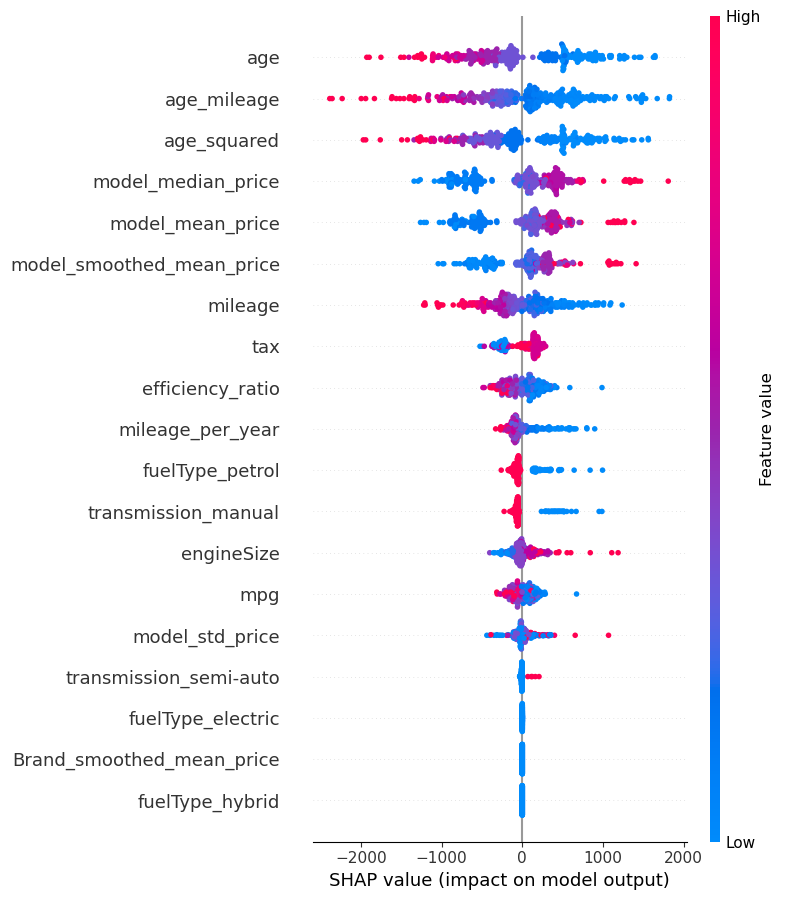

In [54]:
shap.initjs()

sample_opel = X_train_opel_final.sample(300, random_state=69)

explainer_opel = shap.TreeExplainer(rf_opel)
shap_values_opel = explainer_opel.shap_values(sample_opel)

shap.summary_plot(shap_values_opel, sample_opel)

### SHAP on Mercedes

In [49]:
X_train_mercedes = X_train_rfed[X_train_rfed['Brand'] == 'mercedes'].copy()
y_train_mercedes = y_train[X_train_rfed['Brand'] == 'mercedes'].copy()


scaler_mercedes = RobustScaler()
X_train_mercedes_num = pd.DataFrame(
    scaler_mercedes.fit_transform(X_train_mercedes[numeric_cols]),
    columns=numeric_cols,
    index=X_train_mercedes.index
)

In [50]:
X_train_mercedes_cat = pd.get_dummies(X_train_mercedes[categorical_cols], drop_first=True)
X_train_mercedes_final = pd.concat([X_train_mercedes_num, X_train_mercedes_cat], axis=1)


In [51]:
rf_mercedes = RandomForestRegressor(
    n_estimators=2000,
    max_depth=30,
    min_samples_split=3,
    min_samples_leaf=2,
    max_features=0.7,
    bootstrap= True,
    criterion= "squared_error",
    random_state=69,
    n_jobs=-1
)


rf_mercedes.fit(X_train_mercedes_final, y_train_mercedes)

,n_estimators,2000
,criterion,'squared_error'
,max_depth,30
,min_samples_split,3
,min_samples_leaf,2
,min_weight_fraction_leaf,0.0
,max_features,0.7
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [52]:
X_val_mercedes = X_val_rfed[X_val_rfed['Brand'] == 'mercedes'].copy()
y_val_mercedes = y_val[X_val_rfed['Brand'] == 'mercedes'].copy()

X_val_mercedes_num = pd.DataFrame(
    scaler_mercedes.transform(X_val_mercedes[numeric_cols]),
    columns=numeric_cols,
    index=X_val_mercedes.index
)

X_val_mercedes_cat = pd.get_dummies(X_val_mercedes[categorical_cols], drop_first=True)

X_val_mercedes_cat = X_val_mercedes_cat.reindex(columns=X_train_mercedes_cat.columns, fill_value=0)

X_val_mercedes_final = pd.concat([X_val_mercedes_num, X_val_mercedes_cat], axis=1)

y_pred_mercedes = rf_mercedes.predict(X_val_mercedes_final)

c:\Users\liber\anaconda3\envs\ML_env\Lib\site-packages\shap\explainers\_tree.py:253: FutureWarning: In the future, passing feature_perturbation='interventional' without providing a background dataset will raise an error. Please provide a background dataset to continue using the interventional approach or set feature_perturbation='auto' to automatically switch approaches.
  warnings.warn(


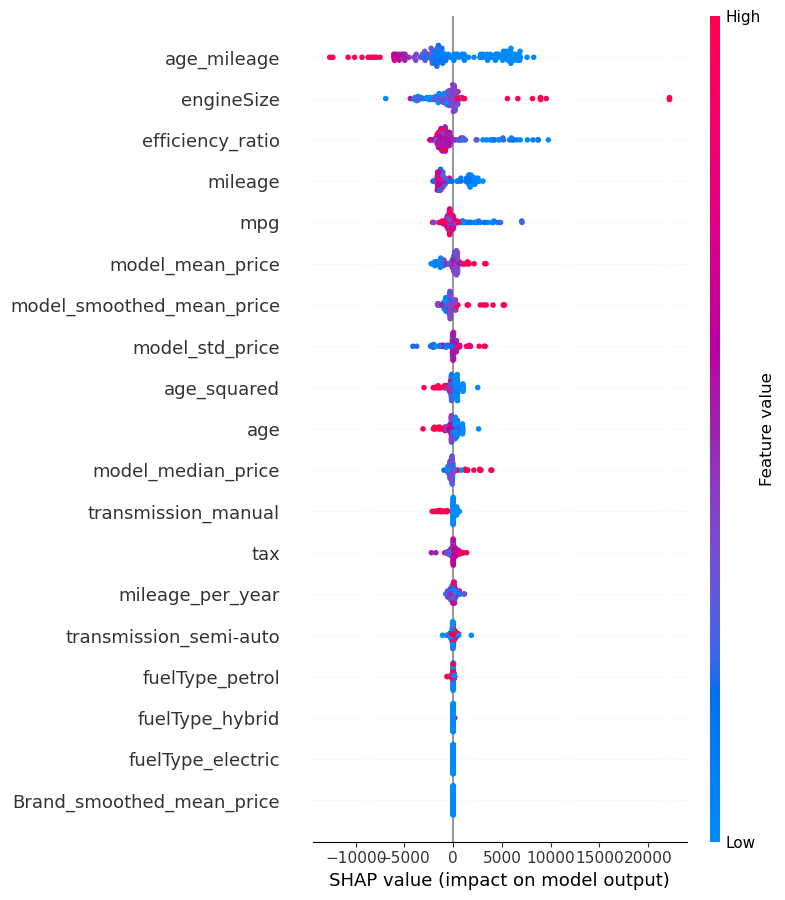

In [57]:
shap.initjs()

sample_mercedes = X_train_mercedes_final.sample(150, random_state=69)

explainer_mercedes = shap.TreeExplainer(
    rf_mercedes,
    feature_perturbation="interventional",
    model_output="raw"
)

shap_values_mercedes = explainer_mercedes.shap_values(
    sample_mercedes,
    approximate=True
)

shap.summary_plot(shap_values_mercedes, sample_mercedes)


## Lazy learners and pretrained models

compare xgboost
compare tabnet

In [64]:
from xgboost import XGBRegressor

In [65]:
XG = XGBRegressor(random_state=69)
XG_trainer = BrandModelTrainer(XG)


XG_trainer.fit(X_train_rfed, y_train)


XG_trainer.evaluate_train(X_train_rfed, y_train)
XG_trainer.evaluate(X_val_rfed, y_val)

XG_trainer.evaluate_train_by_brand(X_train_rfed, y_train)
XG_trainer.evaluate_by_brand(X_val_rfed, y_val)

Training models for 9 brands...

  ✓ opel done.
  ✓ audi done.
  ✓ mercedes done.
  ✓ ford done.
  ✓ bmw done.
  ✓ toyota done.
  ✓ hyundai done.
  ✓ vw done.
  ✓ skoda done.

Training Set Performance (Overall):
  RMSE: 1056.41
  MAE:  724.68
  R²:   0.9879

Validation Set Performance (Overall):
  RMSE: 1956.01
  MAE:  1223.24
  R²:   0.9579

Training Performance per Brand:
   Brand     N        RMSE         MAE       R²
  toyota  3775  535.566778  387.783793 0.992530
 hyundai  2723  556.688258  381.101352 0.991487
    opel  7638  645.718482  472.857400 0.967152
   skoda  3502  651.270228  478.928993 0.988687
    ford 13112  885.518789  651.716039 0.965339
      vw  8479 1020.391478  732.945888 0.982503
    audi  5970 1204.989876  878.853704 0.989358
     bmw  6037 1244.474892  887.498457 0.987986
mercedes  9542 1589.368601 1141.233271 0.977461

Validation Performance per Brand:
   Brand    N        RMSE         MAE       R²
    opel 1907 1219.682420  804.095701 0.882846
 hyundai  687 

,Brand,N,RMSE,MAE,R²
7,opel,1907,1219.682420,804.095701,0.882846
5,hyundai,687,1314.944706,925.447153,0.949667
1,ford,3279,1425.243114,904.842734,0.910580
8,skoda,881,1439.542923,1031.494385,0.945671
3,toyota,941,1449.324582,912.809944,0.953526
0,vw,2125,1712.526986,1151.497635,0.951457
6,audi,1490,2368.667494,1630.463790,0.956104
2,bmw,1505,2673.162522,1635.057302,0.944347
4,mercedes,2380,2773.042457,1826.142513,0.930259


## General model

compare general model on vs our divided one

In [66]:

numeric_cols = X_train_rfed.select_dtypes(include=[np.number]).columns.tolist()
numeric_cols = [c for c in numeric_cols if c != 'price'] 

categorical_cols = ['Brand', 'transmission', 'fuelType']

preprocessor = ColumnTransformer([
    ('num', RobustScaler(), numeric_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
])

rf_pipeline = Pipeline([
    ('preprocess', preprocessor),
    ('estimator', RandomForestRegressor(
        n_estimators=800,
        max_depth=20,
        min_samples_split=3,
        min_samples_leaf=2,
        max_features=0.4,
        min_impurity_decrease=0.01,
        max_samples=None,
        criterion="squared_error",
        bootstrap=True,
        random_state=69,
        n_jobs=-1
    ))
])


rf_pipeline.fit(X_train_rfed, y_train)


y_pred_val = rf_pipeline.predict(X_val_rfed)



rmse = np.sqrt(mean_squared_error(y_val, y_pred_val))
mae = mean_absolute_error(y_val, y_pred_val)
r2 = r2_score(y_val, y_pred_val)

print(f'RMSE: {rmse:.2f}, MAE: {mae:.2f}, R²: {r2:.4f}')


RMSE: 1991.92, MAE: 1227.02, R²: 0.9563
